In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def y(r, x):
    return r*x*(1-x)

## Quadratic Cobweb ##

In [3]:
def cobweb(r, max_iter=200):
    #Initial conditions
    x0 = 0.05
    xpoints=[0.05]
    ypoints=[0.0]
    min_tol=0.01
    currentx=x0
    
    for _ in range(max_iter):
        #Vertical step
        xvert = currentx
        fvert = y(r, xvert)
        xpoints.append(xvert)
        ypoints.append(fvert)
        #Horizontal step
        xhoriz = fvert
        fhoriz = xhoriz
        xpoints.append(xhoriz)
        ypoints.append(fhoriz)

        currentx = xhoriz
    
        if np.abs(fvert - xvert)<min_tol:
            break
    
    return np.array(xpoints), np.array(ypoints)

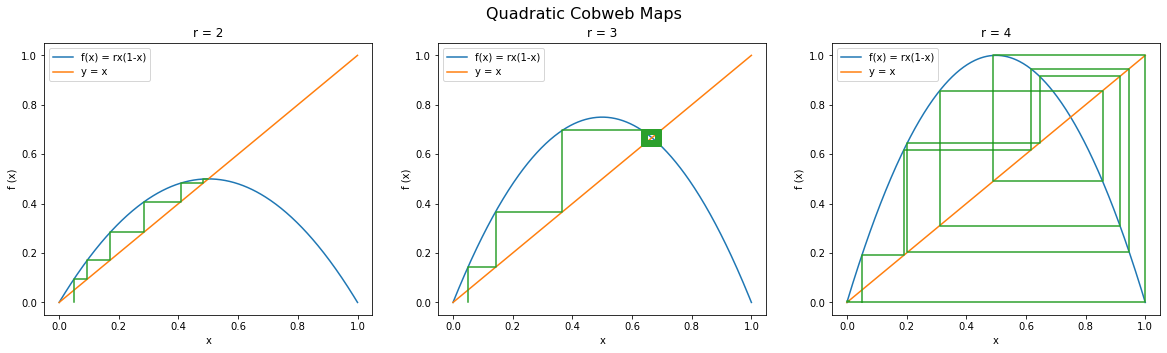

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))

x = np.linspace(0, 1, 400)

r1=2.0
xpoints_0, ypoints_0 = cobweb(r1)
ax[0].plot(x, y(r1, x), label="f(x) = rx(1-x)")
ax[0].plot(x, x, label="y = x")
ax[0].plot(xpoints_0, ypoints_0)
ax[0].set_xlabel("x")
ax[0].set_ylabel("f (x)")
ax[0].set_title(f"r = {r1:.0g}")
ax[0].legend()

r2=3.0
xpoints_1, ypoints_1 = cobweb(r2)
ax[1].plot(x, y(r2, x), label="f(x) = rx(1-x)")
ax[1].plot(x, x, label="y = x")
ax[1].plot(xpoints_1, ypoints_1)
ax[1].set_xlabel("x")
ax[1].set_ylabel("f (x)")
ax[1].set_title(f"r = {r2:.0g}")
ax[1].legend()

r3=4.0
xpoints_2, ypoints_2 = cobweb(r3)
ax[2].plot(x, y(r3, x), label="f(x) = rx(1-x)")
ax[2].plot(x, x, label="y = x")
ax[2].plot(xpoints_2, ypoints_2)
ax[2].set_xlabel("x")
ax[2].set_ylabel("f (x)")
ax[2].set_title(f"r = {r3:.0g}")
ax[2].legend()

plt.suptitle("Quadratic Cobweb Maps", fontsize=16)
plt.show()

## Liapunov Exponent ##

In [5]:
def liapunov_quadratic(r, n_transient=1000, n_iter=5000):
    x=0.5
    
    for i in range(n_transient): #removing unsettled, early iterations
        x = y(r, x)
        
    liap_sum=0.0
    for i in range(n_iter):
        x = y(r, x)
        deriv=abs(r*(1-2*x))
        
        if deriv==0:
            return -np.inf
        liap_sum += np.log(deriv)
        
    return liap_sum/n_iter

#print("λ(2.8) =", liapunov_quadratic(2.8)) #stable
#print("λ(3.6) =", liapunov_quadratic(3.6)) #chaotic

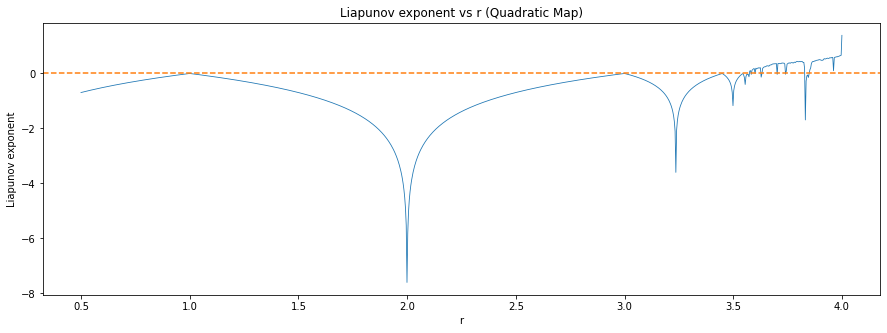

In [6]:
def liapunov_sweep(n_transient=1000, n_iter=5000):
    rs=np.linspace(0.5,  4.0, 1000)
    lambdas=np.empty_like(rs)
    
    for i, r in enumerate(rs):
        lambdas[i]=liapunov_quadratic(r, n_transient=n_transient, n_iter=n_iter)
    
    return rs, lambdas

rs, lambdas = liapunov_sweep()
plt.figure(figsize=(15,5))
plt.plot(rs, lambdas, linewidth=0.8)
plt.axhline(0, linestyle='--', color='tab:orange')
plt.xlabel("r")
plt.ylabel("Liapunov exponent")
plt.title("Liapunov exponent vs r (Quadratic Map)")
plt.show()

## Feigenbaum Constants ##

In [7]:
a1_pn = 0.787
a2_pn = 2.36
a3_pn = 2.91

delta_pn=(a2_pn-a1_pn)/(a3_pn-a2_pn)
print(f"Feigenbaum (PN Junction) is approximately {delta_pn:0.6g}.")

Feigenbaum (PN Junction) is approximately 2.86.


## Information Dimension ##

In [8]:
#isolating the desired data
pn=np.loadtxt("(official) calcorr pn data.txt")
bb=np.loadtxt("(official) calcorr bb data.txt")

x_pn_raw=pn[:, 0]
x_bb_raw=bb[:, 0]
y_pn_raw=pn[:, 4] #col 4 is highest embedding dimension with enough data
y_bb_raw=bb[:, 4]

#removing infinte values in both columns
mask_pn=np.isfinite(x_pn_raw) & np.isfinite(y_pn_raw)
mask_bb=np.isfinite(x_bb_raw) & np.isfinite(y_bb_raw)

x_pn=x_pn_raw[mask_pn]
x_bb=x_bb_raw[mask_bb]
y_pn=y_pn_raw[mask_pn]
y_bb=y_bb_raw[mask_bb]

In [9]:
#linear regression
slope_pn, intercept_pn=np.polyfit(x_pn, y_pn, 1) #dof=1
D_pn=2*slope_pn

slope_bb, intercept_bb=np.polyfit(x_bb, y_bb, 1) #dof=1
D_bb=2*slope_bb

def r_squared(x, y, slope, intercept):
    y_pred=slope*x+intercept
    ss_res=np.sum((y-y_pred)**2)
    ss_tot=np.sum((y-np.mean(y))**2)
    return 1-(ss_res/ss_tot)

r2_pn = r_squared(x_pn, y_pn, slope_pn, intercept_pn)
r2_bb = r_squared(x_bb, y_bb, slope_bb, intercept_bb)

print("x range:", x_pn.min(), "to", x_pn.max())
print("y range:", y_pn.min(), "to", y_pn.max())
print("N points:", len(x))

x range: 5.807 to 12.728
y range: 1.0 to 12.059
N points: 400


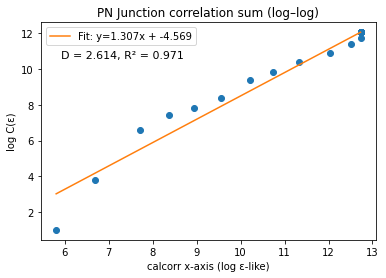

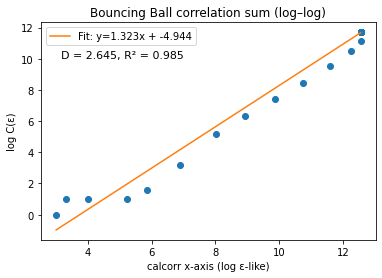

In [10]:
#plotting
plt.figure()
plt.plot(x_pn, y_pn, 'o')
plt.plot(x_pn, slope_pn*x_pn+intercept_pn, 'tab:orange', label=f"Fit: y={slope_pn:.3f}x + {intercept_pn:.3f}")
plt.xlabel("calcorr x-axis (log ε-like)")
plt.ylabel("log C(ε)")
plt.title("PN Junction correlation sum (log–log)")
plt.text(0.06, 0.85,
         f"D = {D_pn:.3f}, R² = {r2_pn:.3f}",
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='center')
plt.legend()
plt.show()

plt.figure()
plt.plot(x_bb, y_bb, 'o')
plt.plot(x_bb, slope_bb*x_bb+intercept_bb, 'tab:orange', label=f"Fit: y={slope_bb:.3f}x + {intercept_bb:.3f}")
plt.xlabel("calcorr x-axis (log ε-like)")
plt.ylabel("log C(ε)")
plt.title("Bouncing Ball correlation sum (log–log)")
plt.text(0.06, 0.85,
         f"D = {D_bb:.3f}, R² = {r2_bb:.3f}",
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='center')
plt.legend()
plt.show()

In [11]:
#by far, the easiest analysis completed. ease attributed to bad data and the assistance of chatgpt